# ObRail Europe — Classification des liaisons ferroviaires candidates à la substitution avion → train

**Projet MSPR — RNCP36581 Développeur en Intelligence Artificielle et Data Science**  
**École EPSI — Bloc 2 & 4**

---

## Problématique

Identifier automatiquement quelles liaisons ferroviaires sont candidates à remplacer un vol aérien.  
Problème de **classification binaire** : substituable (`1`) ou non (`0`).

La variable cible n'existe pas dans les données — elle est construite par règles métier :
- distance entre 300 et 1 500 km
- durée inférieure à 480 min (8h)

Trois modèles comparés : Régression Logistique (baseline), Random Forest, XGBoost.

## Section 0 — Imports et configuration

Bibliothèques et paramètres globaux.  
`RANDOM_STATE = 42` fixé sur tous les appels aléatoires (splits, initialisations de modèles) pour garantir la reproductibilité des résultats.  
Création des dossiers `figures/` et `models/` au démarrage.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score, roc_curve
)

import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

# Seed global pour la reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Création des dossiers de sortie
os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Style visuel uniforme
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Imports OK — dossiers figures/ et models/ créés.')

Imports OK — dossiers figures/ et models/ créés.


## Section 1 — Chargement et aperçu des données

Chargement de `eu_trips_v2.csv` (∼142 000 trajets, FR / ES / IT / DE).  
`low_memory=False` évite les erreurs d'inférence de types sur les colonnes mixtes.  
On vérifie les dimensions, les types et les valeurs manquantes avant tout traitement.

In [2]:
# Chargement du dataset
df = pd.read_csv('eu_trips_v2.csv', low_memory=False)

print(f'Dimensions du dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print()
print('Types des colonnes :')
print(df.dtypes)
print()
print('Premières lignes :')
df.head()

Dimensions du dataset : 142,420 lignes × 24 colonnes

Types des colonnes :
arrival_minutes          float64
departure_minutes        float64
destination_stop_id       object
destination_stop_lat     float64
destination_stop_lon     float64
destination_stop_name     object
duration_minutes         float64
n_stops                  float64
origin_stop_id            object
origin_stop_lat          float64
origin_stop_lon          float64
origin_stop_name          object
route_id                  object
route_long_name           object
route_type                 int64
service_id                object
trip_id                   object
country                   object
distance_km              float64
type_train                object
consommation_energy      float64
gco2_per_kwh             float64
consommation_totale      float64
co2_estime               float64
dtype: object

Premières lignes :


,arrival_minutes,departure_minutes,destination_stop_id,destination_stop_lat,destination_stop_lon,destination_stop_name,duration_minutes,n_stops,origin_stop_id,origin_stop_lat,...,route_type,service_id,trip_id,country,distance_km,type_train,consommation_energy,gco2_per_kwh,consommation_totale,co2_estime
0,672.0,556.0,StopPoint:OCETrain TER-87713040,47.323411,5.027256,Dijon,116.0,10.0,StopPoint:OCETrain TER-87723197,45.760596,...,2,1,OCESN117756F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.25,electric,20.0,21.7,3485.01,75624.712
1,791.0,676.0,StopPoint:OCETrain TER-87713040,47.323411,5.027256,Dijon,115.0,10.0,StopPoint:OCETrain TER-87723197,45.760596,...,2,2,OCESN117758F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.25,electric,20.0,21.7,3485.01,75624.712
2,922.0,800.0,StopPoint:OCETrain TER-87713040,47.323411,5.027256,Dijon,122.0,2.0,StopPoint:OCETrain TER-87723197,45.760596,...,2,3,OCESN117760F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.25,electric,20.0,21.7,3485.01,75624.712
3,911.0,796.0,StopPoint:OCETrain TER-87713040,47.323411,5.027256,Dijon,115.0,10.0,StopPoint:OCETrain TER-87723197,45.760596,...,2,4,OCESN117760F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.25,electric,20.0,21.7,3485.01,75624.712
4,911.0,796.0,StopPoint:OCETrain TER-87713040,47.323411,5.027256,Dijon,115.0,10.0,StopPoint:OCETrain TER-87723197,45.760596,...,2,5,OCESN117760F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.25,electric,20.0,21.7,3485.01,75624.712


In [3]:
# Statistiques descriptives des variables numériques
print('Statistiques descriptives :')
df.describe()

Statistiques descriptives :


,arrival_minutes,departure_minutes,destination_stop_lat,destination_stop_lon,duration_minutes,n_stops,origin_stop_lat,origin_stop_lon,route_type,distance_km,consommation_energy,gco2_per_kwh,consommation_totale,co2_estime
count,142420.000000,142420.000000,142420.000000,142420.000000,142420.000000,142420.000000,142420.000000,142420.000000,142420.000000,142420.000000,142420.000000,142420.000000,142420.000000,1.424200e+05
mean,910.979809,815.612704,47.061062,5.842881,95.367106,14.155491,47.052230,5.838057,2.633268,99.629033,15.692670,204.738443,1774.381423,2.511654e+05
std,338.930380,329.356794,4.103998,4.294656,82.310062,9.516800,4.105237,4.307142,10.051291,142.411238,4.951806,145.742048,2914.671643,5.394809e+05
min,21.000000,0.000000,40.541542,-4.480306,0.000000,2.000000,40.541542,-4.480306,0.000000,20.004000,10.000000,21.700000,200.044000,4.362003e+03
25%,626.000000,530.000000,41.799375,2.183104,52.000000,7.000000,41.799375,2.182250,2.000000,29.581000,10.000000,21.700000,430.935000,5.755193e+04
50%,920.000000,822.000000,48.185100,5.714548,70.000000,12.000000,48.166077,5.714548,2.000000,48.109000,20.000000,140.000000,687.157000,1.206695e+05
75%,1184.000000,1086.000000,50.350930,9.264624,104.000000,18.000000,50.332607,9.295828,2.000000,85.026000,20.000000,363.000000,1290.553000,2.292892e+05
max,2295.783333,1987.000000,55.672720,23.494036,1425.000000,202.000000,55.672720,23.494036,200.000000,937.920000,20.000000,363.000000,18758.399000,6.519651e+06


In [4]:
# Vérification des valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valeurs manquantes': missing, '% du total': missing_pct})
print('Valeurs manquantes par colonne :')
print(missing_df[missing_df['Valeurs manquantes'] > 0])

if missing_df['Valeurs manquantes'].sum() == 0:
    print('Aucune valeur manquante détectée dans le dataset.')

Valeurs manquantes par colonne :
                 Valeurs manquantes  % du total
route_long_name               63327       44.46


## Section 2 — Création de la variable cible

Le dataset ne contient pas de cible préexistante.  
On la construit à partir des seuils retenus dans les études Transport & Environnement et Back-on-Track (2021) :

- `distance_km` ∈ [300, 1500] — corridor où le train peut concurrencer l'avion
- `duration_minutes` < 480 — seuil d'acceptabilité pour un voyageur

`substitution_avion = 1` si les deux conditions sont remplies, `0` sinon.  
C'est une **labellisation par règles**, pas une observation terrain — voir les limites en fin de notebook.

In [5]:
# Création de la variable cible selon les règles métier
df['substitution_avion'] = (
    (df['distance_km'] >= 300) &
    (df['distance_km'] <= 1500) &
    (df['duration_minutes'] < 480)
).astype(int)

print('Distribution de la variable cible :')
counts = df['substitution_avion'].value_counts()
pct = (counts / len(df) * 100).round(2)
result = pd.DataFrame({'Effectif': counts, 'Pourcentage (%)': pct})
result.index = result.index.map({0: 'Non substituable (0)', 1: 'Substituable (1)'})
print(result)

Distribution de la variable cible :
                      Effectif  Pourcentage (%)
substitution_avion                             
Non substituable (0)    130470            91.61
Substituable (1)         11950             8.39


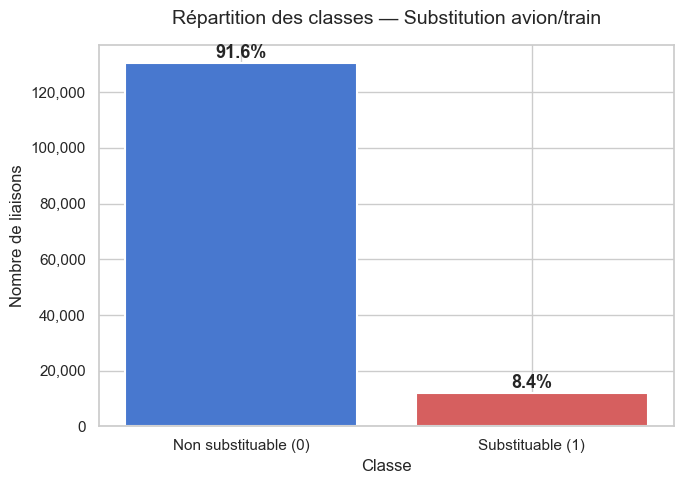

Figure sauvegardée : figures/01_distribution_classes.png


In [6]:
# Visualisation de la répartition des classes
fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#4878CF', '#D65F5F']
labels = ['Non substituable (0)', 'Substituable (1)']
values = [df['substitution_avion'].value_counts()[0], df['substitution_avion'].value_counts()[1]]
pcts = [v / len(df) * 100 for v in values]

bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1.5)

# Annotations des pourcentages
for bar, p in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 500,
            f'{p:.1f}%',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_title('Répartition des classes — Substitution avion/train', fontsize=14, pad=15)
ax.set_ylabel('Nombre de liaisons', fontsize=12)
ax.set_xlabel('Classe', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('figures/01_distribution_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/01_distribution_classes.png')

**Équilibre des classes :** si la classe 1 représente moins de 20 %, on parle de déséquilibre modéré.  
Conséquences pratiques : utiliser `scale_pos_weight` (XGBoost) et `class_weight='balanced'` (LR), et préférer le F1-score à l'accuracy comme métrique principale.

## Section 3 — Analyse exploratoire (EDA)

Cinq visualisations pour comprendre les distributions et les relations avec la cible avant de construire le modèle :
- distributions de `distance_km` et `duration_minutes` selon la classe
- répartition par pays et par type de traction
- corrélations entre les variables numériques

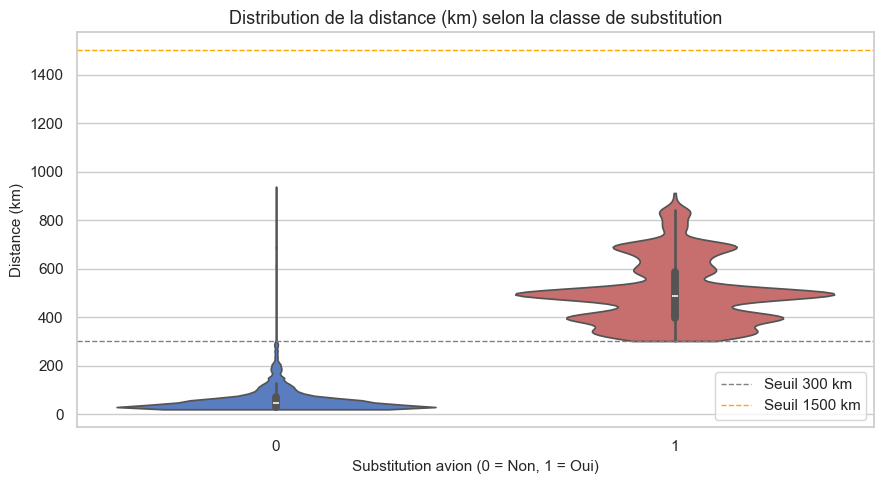

Figure sauvegardée : figures/02_distribution_distance_classe.png


In [7]:
# Graphique 1 — Distribution de distance_km selon la classe
fig, ax = plt.subplots(figsize=(9, 5))

sns.violinplot(
    data=df, x='substitution_avion', y='distance_km',
    palette=['#4878CF', '#D65F5F'], ax=ax, cut=0
)

ax.set_title('Distribution de la distance (km) selon la classe de substitution', fontsize=13)
ax.set_xlabel('Substitution avion (0 = Non, 1 = Oui)', fontsize=11)
ax.set_ylabel('Distance (km)', fontsize=11)
ax.axhline(300, color='gray', linestyle='--', linewidth=1, label='Seuil 300 km')
ax.axhline(1500, color='orange', linestyle='--', linewidth=1, label='Seuil 1500 km')
ax.legend()

plt.tight_layout()
plt.savefig('figures/02_distribution_distance_classe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/02_distribution_distance_classe.png')

**Distance :** les substituables se concentrent mécaniquement dans [300, 1500] km — c'est la règle de construction de la cible.  
`distance_km` sera le prédicteur dominant ; à garder à l'esprit lors de l'interprétation des importances.

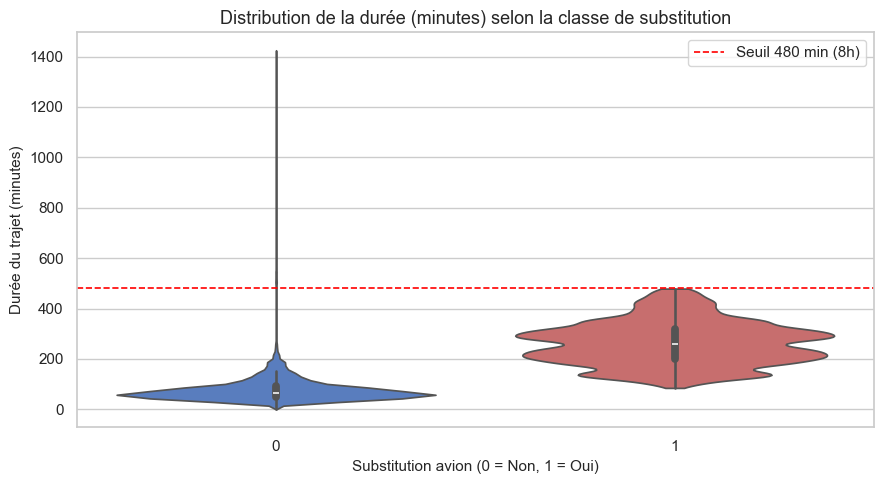

Figure sauvegardée : figures/03_distribution_duree_classe.png


In [8]:
# Graphique 2 — Distribution de duration_minutes selon la classe
fig, ax = plt.subplots(figsize=(9, 5))

sns.violinplot(
    data=df, x='substitution_avion', y='duration_minutes',
    palette=['#4878CF', '#D65F5F'], ax=ax, cut=0
)

ax.set_title('Distribution de la durée (minutes) selon la classe de substitution', fontsize=13)
ax.set_xlabel('Substitution avion (0 = Non, 1 = Oui)', fontsize=11)
ax.set_ylabel('Durée du trajet (minutes)', fontsize=11)
ax.axhline(480, color='red', linestyle='--', linewidth=1.2, label='Seuil 480 min (8h)')
ax.legend()

plt.tight_layout()
plt.savefig('figures/03_distribution_duree_classe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/03_distribution_duree_classe.png')

**Durée :** les substituables sont strictement sous les 480 min ; les non-substituables couvrent tout le spectre (trajets très courts et très longs).  
Deuxième feature discriminante, complémentaire à la distance.

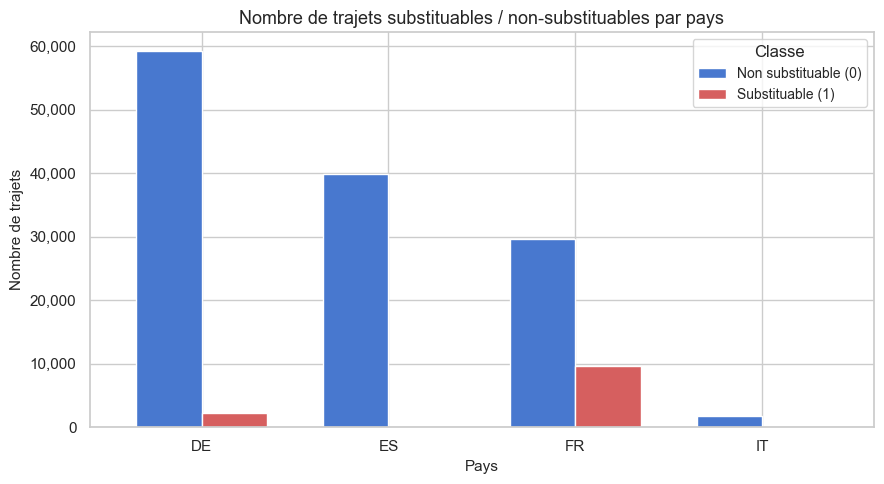

Figure sauvegardée : figures/04_repartition_pays_classe.png


In [9]:
# Graphique 3 — Répartition par pays
country_counts = df.groupby(['country', 'substitution_avion']).size().unstack(fill_value=0)
country_counts.columns = ['Non substituable (0)', 'Substituable (1)']

fig, ax = plt.subplots(figsize=(9, 5))
country_counts.plot(kind='bar', ax=ax, color=['#4878CF', '#D65F5F'],
                    edgecolor='white', width=0.7)

ax.set_title('Nombre de trajets substituables / non-substituables par pays', fontsize=13)
ax.set_xlabel('Pays', fontsize=11)
ax.set_ylabel('Nombre de trajets', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Classe', fontsize=10)

plt.tight_layout()
plt.savefig('figures/04_repartition_pays_classe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/04_repartition_pays_classe.png')

**Pays :** volumes et ratios varient selon les réseaux nationaux.  
La France dispose d'un réseau TGV adapté aux distances intermédiaires ; l'Italie et l'Espagne présentent des profils liés à leur géographie.  
Ces disparités justifient d'inclure `country` comme feature.

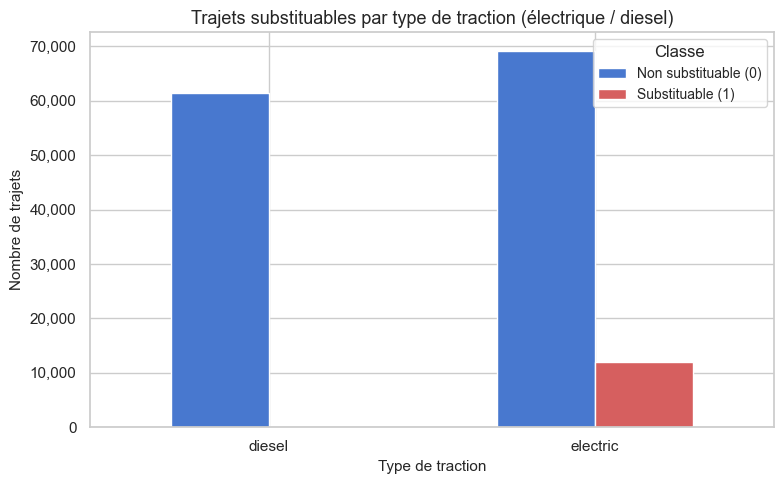

Figure sauvegardée : figures/05_repartition_type_train_classe.png


In [10]:
# Graphique 4 — Répartition par type de traction
train_counts = df.groupby(['type_train', 'substitution_avion']).size().unstack(fill_value=0)
train_counts.columns = ['Non substituable (0)', 'Substituable (1)']

fig, ax = plt.subplots(figsize=(8, 5))
train_counts.plot(kind='bar', ax=ax, color=['#4878CF', '#D65F5F'],
                  edgecolor='white', width=0.6)

ax.set_title('Trajets substituables par type de traction (électrique / diesel)', fontsize=13)
ax.set_xlabel('Type de traction', fontsize=11)
ax.set_ylabel('Nombre de trajets', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Classe', fontsize=10)

plt.tight_layout()
plt.savefig('figures/05_repartition_type_train_classe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/05_repartition_type_train_classe.png')

**Type de traction :** les lignes électriques dominent dans la classe substituable — cohérent avec la réalité : TGV, AVE, Frecciarossa et ICE sont tous électrifiés et couvrent les distances visées.  
Le diesel reste concentré sur les lignes régionales courtes, hors corridor cible.

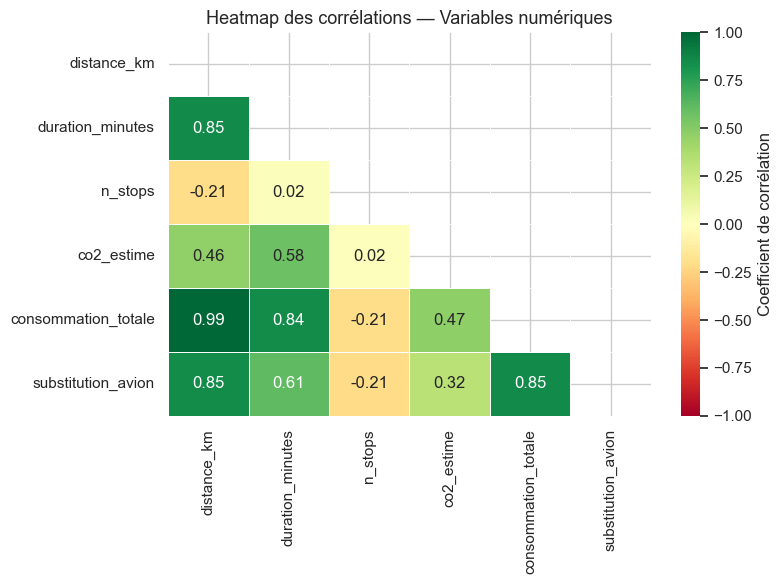

Figure sauvegardée : figures/06_heatmap_correlation.png


In [11]:
# Graphique 5 — Heatmap de corrélation
num_cols = ['distance_km', 'duration_minutes', 'n_stops', 'co2_estime',
            'consommation_totale', 'substitution_avion']

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # triangle supérieur masqué

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Coefficient de corrélation'}
)

ax.set_title('Heatmap des corrélations — Variables numériques', fontsize=13)
plt.tight_layout()
plt.savefig('figures/06_heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/06_heatmap_correlation.png')

**Corrélations :** `distance_km`, `consommation_totale` et `co2_estime` sont fortement colinéaires — la consommation est calculée directement depuis la distance (voir enrichissement du notebook 00).  
Cette multicolinéarité peut déstabiliser les coefficients de la régression logistique ; Random Forest et XGBoost y sont insensibles.

## Section 4 — Préparation des données

Quatre opérations avant l'entraînement :
- sélection des features pertinentes et exclusion des colonnes redondantes ou non informatives
- encodage des variables catégorielles (`type_train`, `country`)
- suppression des lignes avec valeurs manquantes sur les features retenues
- split stratifié 70 / 15 / 15 et normalisation pour la régression logistique

### 4.1 — Sélection des features

Features retenues : `distance_km`, `duration_minutes`, `n_stops`, `co2_estime`, `consommation_totale`, `type_train`, `country`.

Colonnes exclues :
- coordonnées GPS : redondantes avec `distance_km` (calculée par haversine depuis ces mêmes coordonnées)
- `arrival_minutes`, `departure_minutes` : non pertinents pour une décision de substitution
- `route_id`, `trip_id`, `service_id` : identifiants sans pouvoir prédictif
- `gco2_per_kwh`, `consommation_energy` : déjà incorporés dans `co2_estime` et `consommation_totale`
- `origin_stop_name`, `destination_stop_name` : haute cardinalité, nécessiterait un encodage spécifique non justifié ici
- `route_type` : constant dans ce dataset (valeur 2 partout)

In [12]:
# Sélection des features et de la cible
features = ['distance_km', 'duration_minutes', 'n_stops',
            'co2_estime', 'consommation_totale', 'type_train', 'country']
target = 'substitution_avion'

print(f'Features sélectionnées ({len(features)}) : {features}')
print(f'Variable cible : {target}')

Features sélectionnées (7) : ['distance_km', 'duration_minutes', 'n_stops', 'co2_estime', 'consommation_totale', 'type_train', 'country']
Variable cible : substitution_avion


### 4.2 — Encodage des variables catégorielles

`LabelEncoder` retenu plutôt que OneHotEncoding :
- `type_train` a 2 modalités, `country` en a 4 — le surcoût du One-Hot est négligeable mais inutile
- pour les arbres (RF, XGBoost), un entier ordinal suffit ; les seuils isolent les valeurs sans dépendre de l'ordre
- pour la régression logistique, l'ordinalité artificielle introduit un biais léger — limite connue, signalée en conclusion

In [13]:
# Copie du dataset et encodage des catégorielles
df_model = df[features + [target]].copy()

le_type_train = LabelEncoder()
le_country = LabelEncoder()

df_model['type_train'] = le_type_train.fit_transform(df_model['type_train'])
df_model['country'] = le_country.fit_transform(df_model['country'])

print('Encodage type_train :', dict(zip(le_type_train.classes_, le_type_train.transform(le_type_train.classes_))))
print('Encodage country    :', dict(zip(le_country.classes_, le_country.transform(le_country.classes_))))
print()
print('Aperçu après encodage :')
df_model.head()

Encodage type_train : {'diesel': np.int64(0), 'electric': np.int64(1)}
Encodage country    : {'DE': np.int64(0), 'ES': np.int64(1), 'FR': np.int64(2), 'IT': np.int64(3)}

Aperçu après encodage :


,distance_km,duration_minutes,n_stops,co2_estime,consommation_totale,type_train,country,substitution_avion
0,174.25,116.0,10.0,75624.712,3485.01,1,2,0
1,174.25,115.0,10.0,75624.712,3485.01,1,2,0
2,174.25,122.0,2.0,75624.712,3485.01,1,2,0
3,174.25,115.0,10.0,75624.712,3485.01,1,2,0
4,174.25,115.0,10.0,75624.712,3485.01,1,2,0


### 4.3 — Gestion des valeurs manquantes

Vérification et suppression des lignes incomplètes sur les features retenues.  
Le dataset `eu_trips_v2` a été construit proprement dans le notebook 00 ; on s'attend à peu ou pas de NaN.

In [14]:
# Vérification des NaN sur les features retenues
nan_count = df_model.isnull().sum()
print('Valeurs manquantes sur les features sélectionnées :')
print(nan_count)

initial_size = len(df_model)
df_model = df_model.dropna()
final_size = len(df_model)

print(f'\nLignes supprimées : {initial_size - final_size} ({(initial_size - final_size) / initial_size * 100:.2f}%)')
print(f'Dataset final     : {final_size:,} lignes')

Valeurs manquantes sur les features sélectionnées :
distance_km            0
duration_minutes       0
n_stops                0
co2_estime             0
consommation_totale    0
type_train             0
country                0
substitution_avion     0
dtype: int64

Lignes supprimées : 0 (0.00%)
Dataset final     : 142,420 lignes


### 4.4 — Split train / validation / test

Division **70 / 15 / 15** :
- train (70 %) : entraînement des modèles
- validation (15 %) : comparaison et sélection du meilleur
- test (15 %) : évaluation finale, jamais vu pendant les étapes précédentes

`stratify=y` assure que la proportion de la classe 1 est identique dans les trois ensembles.

In [15]:
X = df_model[features]
y = df_model[target]

# Première coupe : 70% train, 30% temporaire
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Deuxième coupe : 50% val, 50% test (soit 15% / 15% du total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Train      : {len(X_train):>7,} lignes  — {y_train.mean():.3f} proportion classe 1')
print(f'Validation : {len(X_val):>7,} lignes  — {y_val.mean():.3f} proportion classe 1')
print(f'Test       : {len(X_test):>7,} lignes  — {y_test.mean():.3f} proportion classe 1')
print(f'Total      : {len(X_train) + len(X_val) + len(X_test):>7,} lignes')

Train      :  99,694 lignes  — 0.084 proportion classe 1
Validation :  21,363 lignes  — 0.084 proportion classe 1
Test       :  21,363 lignes  — 0.084 proportion classe 1
Total      : 142,420 lignes


### 4.5 — Normalisation (Régression Logistique uniquement)

La régression logistique est sensible aux échelles : `co2_estime` en milliers contre `n_stops` entre 0 et ~15 — sans normalisation, les coefficients seraient écrasés par les variables à grandes valeurs.  
`StandardScaler` centre chaque feature à µ = 0, σ = 1.

Random Forest et XGBoost travaillent sur des seuils ordinaux — l'échelle absolue n'a aucun impact.

**Règle importante :** `.fit_transform()` uniquement sur le train, `.transform()` sur val et test pour éviter toute fuite d'information.

In [16]:
# Normalisation — fit sur le train uniquement pour éviter la fuite de données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('Normalisation appliquée.')
print(f'Moyenne X_train avant scaling : distance_km = {X_train["distance_km"].mean():.1f} km')
print(f'Moyenne X_train après scaling : {X_train_scaled[:, 0].mean():.6f}  (≈ 0)')
print(f'Std X_train après scaling     : {X_train_scaled[:, 0].std():.6f}  (≈ 1)')

Normalisation appliquée.
Moyenne X_train avant scaling : distance_km = 99.6 km
Moyenne X_train après scaling : 0.000000  (≈ 0)
Std X_train après scaling     : 1.000000  (≈ 1)


## Section 5 — Entraînement des 3 modèles

Un modèle linéaire (baseline), un ensemble par bagging, un ensemble par boosting.  
Objectif : couvrir des familles algorithmiques différentes pour identifier la plus adaptée au problème.

### Modèle 1 — Régression Logistique (baseline)

Modèle linéaire : estime la probabilité d'appartenir à la classe 1 via une fonction sigmoïde.  
Point fort : interprétable directement via ses coefficients — utile pour justifier les prédictions auprès de parties prenantes non techniques.  
Limite attendue : la frontière de décision est linéaire, ce qui ne colle probablement pas avec la construction de la cible (deux seuils fixes sur deux variables).

In [17]:
# Régression Logistique — entraînement sur données normalisées
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_val_scaled)
y_proba_lr = lr.predict_proba(X_val_scaled)[:, 1]

print('=== Régression Logistique — Validation ===')
print(classification_report(y_val, y_pred_lr, target_names=['Non substituable', 'Substituable']))
print(f'AUC-ROC : {roc_auc_score(y_val, y_proba_lr):.4f}')

=== Régression Logistique — Validation ===
                  precision    recall  f1-score   support

Non substituable       1.00      0.98      0.99     19570
    Substituable       0.85      0.99      0.92      1793

        accuracy                           0.98     21363
       macro avg       0.92      0.99      0.95     21363
    weighted avg       0.99      0.98      0.99     21363



AUC-ROC : 0.9969


### Modèle 2 — Random Forest

Ensemble de 100 arbres de décision entraînés en parallèle sur des sous-échantillons aléatoires (bagging).  
Vote majoritaire pour la prédiction finale.  
Gère naturellement les non-linéarités et les interactions entre features, sans normalisation.  
Inconvénient : moins interprétable qu'un modèle linéaire, plus gourmand en mémoire sur de grands ensembles.

In [18]:
# Random Forest — entraînement sur données brutes (pas besoin de normalisation)
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'  # gestion du déséquilibre de classes
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
y_proba_rf = rf.predict_proba(X_val)[:, 1]

print('=== Random Forest — Validation ===')
print(classification_report(y_val, y_pred_rf, target_names=['Non substituable', 'Substituable']))
print(f'AUC-ROC : {roc_auc_score(y_val, y_proba_rf):.4f}')

=== Random Forest — Validation ===
                  precision    recall  f1-score   support

Non substituable       1.00      1.00      1.00     19570
    Substituable       1.00      1.00      1.00      1793

        accuracy                           1.00     21363
       macro avg       1.00      1.00      1.00     21363
    weighted avg       1.00      1.00      1.00     21363

AUC-ROC : 1.0000


### Modèle 3 — XGBoost

Boosting gradient : les arbres sont construits séquentiellement, chaque arbre corrige les erreurs du précédent.  
`scale_pos_weight` compense le déséquilibre de classes sans sur-échantillonner les données.  
Algorithme de référence sur les données tabulaires en compétitions et en production industrielle.  
Plus sensible aux hyperparamètres que Random Forest — d'où l'optimisation en section 7.

In [19]:
# Calcul du ratio de déséquilibre pour scale_pos_weight
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Ratio déséquilibre (négatifs/positifs) : {scale:.2f}')

# XGBoost — entraînement
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=scale,  # compense le déséquilibre de classes
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)
y_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

print('=== XGBoost — Validation ===')
print(classification_report(y_val, y_pred_xgb, target_names=['Non substituable', 'Substituable']))
print(f'AUC-ROC : {roc_auc_score(y_val, y_proba_xgb):.4f}')

Ratio déséquilibre (négatifs/positifs) : 10.92


=== XGBoost — Validation ===
                  precision    recall  f1-score   support

Non substituable       1.00      1.00      1.00     19570
    Substituable       0.98      1.00      0.99      1793

        accuracy                           1.00     21363
       macro avg       0.99      1.00      0.99     21363
    weighted avg       1.00      1.00      1.00     21363

AUC-ROC : 1.0000


## Section 6 — Évaluation et comparaison des modèles

Comparaison sur le jeu de **validation** (non vu pendant l'entraînement).  
Métriques suivies :
- **Accuracy** : proportion globale de bonnes prédictions
- **F1-score macro** : moyenne des F1 par classe, adapté au déséquilibre
- **Recall classe 1** : proportion de liaisons substituables correctement détectées — métrique prioritaire pour ObRail (manquer une liaison = opportunité perdue)
- **AUC-ROC** : capacité discriminante quel que soit le seuil de décision

In [20]:
# 6.1 — Tableau comparatif des métriques
def get_metrics(y_true, y_pred, y_proba, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Modèle': model_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'F1-score (macro)': round(f1_score(y_true, y_pred, average='macro'), 4),
        'Recall classe 1': round(report['1']['recall'], 4),
        'Précision classe 1': round(report['1']['precision'], 4),
        'AUC-ROC': round(roc_auc_score(y_true, y_proba), 4)
    }

metrics_table = pd.DataFrame([
    get_metrics(y_val, y_pred_lr,  y_proba_lr,  'Régression Logistique'),
    get_metrics(y_val, y_pred_rf,  y_proba_rf,  'Random Forest'),
    get_metrics(y_val, y_pred_xgb, y_proba_xgb, 'XGBoost'),
])
metrics_table = metrics_table.set_index('Modèle')

print('Tableau comparatif des métriques (jeu de validation) :')
metrics_table.style.highlight_max(axis=0, color='#90EE90')

Tableau comparatif des métriques (jeu de validation) :


,Accuracy,F1-score (macro),Recall classe 1,Précision classe 1,AUC-ROC
Modèle,,,,,
Régression Logistique,0.984700,0.953900,0.994400,0.849500,0.996900
Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
XGBoost,0.997900,0.993200,1.000000,0.975500,1.000000


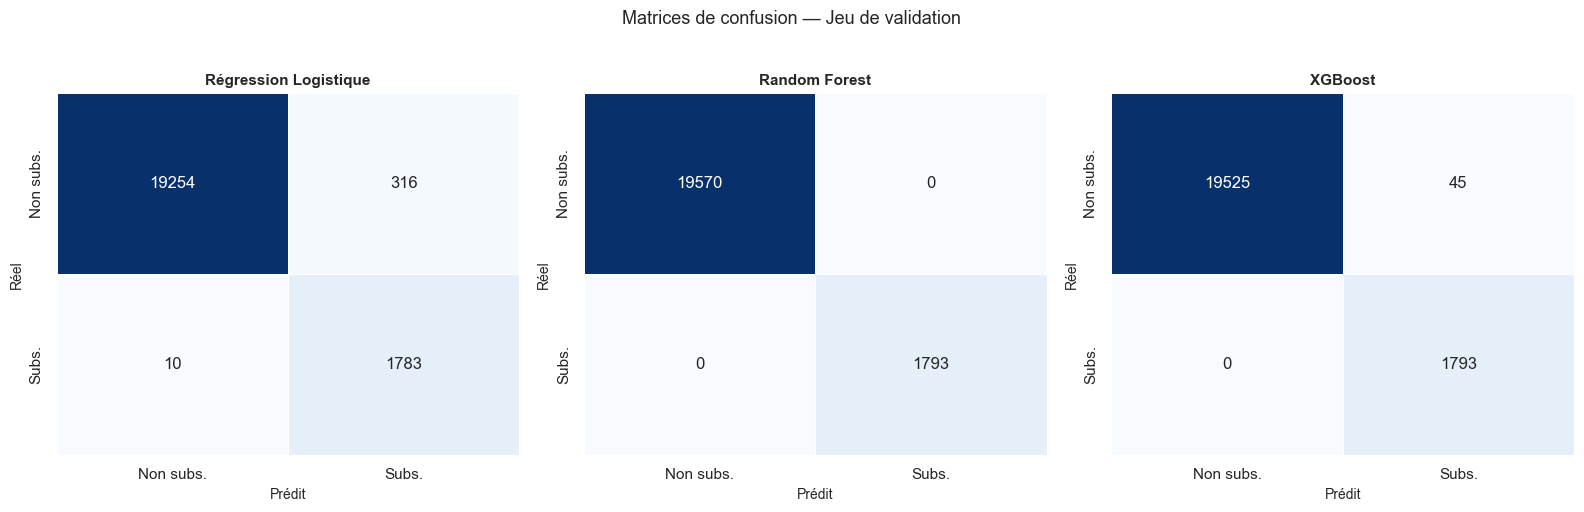

Figure sauvegardée : figures/07_matrices_confusion.png


In [21]:
# 6.2 — Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_info = [
    ('Régression Logistique', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb),
]

for ax, (name, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Non subs.', 'Subs.'],
        yticklabels=['Non subs.', 'Subs.'],
        ax=ax, linewidths=0.5, cbar=False
    )
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Prédit', fontsize=10)
    ax.set_ylabel('Réel', fontsize=10)

fig.suptitle('Matrices de confusion — Jeu de validation', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/07_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/07_matrices_confusion.png')

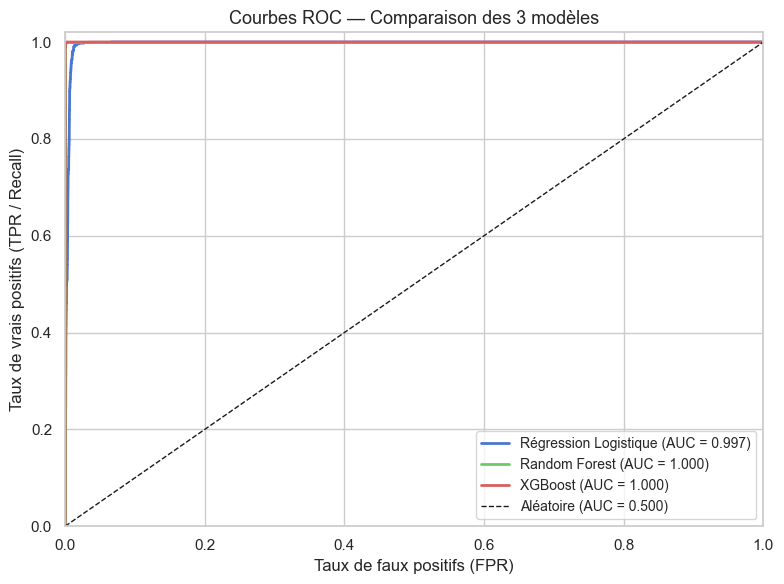

Figure sauvegardée : figures/08_courbes_roc.png


In [22]:
# 6.3 — Courbes ROC comparées
fig, ax = plt.subplots(figsize=(8, 6))

roc_models = [
    ('Régression Logistique', y_proba_lr, '#4878CF'),
    ('Random Forest', y_proba_rf, '#6ACC65'),
    ('XGBoost', y_proba_xgb, '#D65F5F'),
]

for name, y_proba, color in roc_models:
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc = roc_auc_score(y_val, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

# Ligne de référence (classificateur aléatoire)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire (AUC = 0.500)')

ax.set_xlabel('Taux de faux positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de vrais positifs (TPR / Recall)', fontsize=12)
ax.set_title('Courbes ROC — Comparaison des 3 modèles', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('figures/08_courbes_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/08_courbes_roc.png')

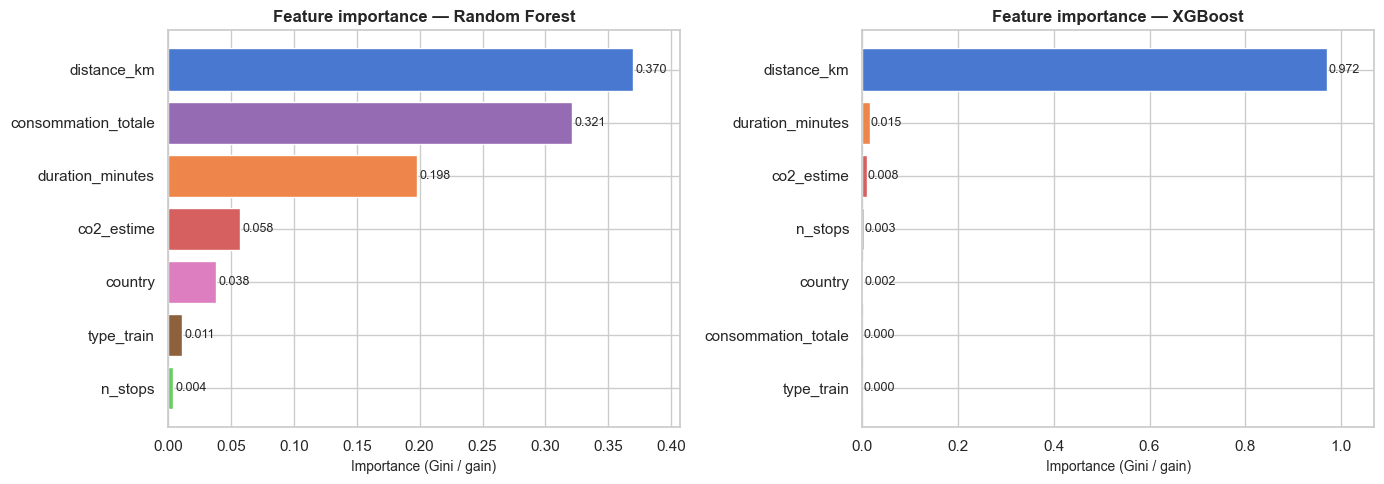

Figure sauvegardée : figures/09_feature_importance.png


In [23]:
# 6.4 — Feature importance : Random Forest et XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model, model_name) in zip(axes, [(rf, 'Random Forest'), (xgb_model, 'XGBoost')]):
    importances = model.feature_importances_
    indices = np.argsort(importances)
    feature_names = np.array(features)

    colors = sns.color_palette('muted', len(features))
    ax.barh(feature_names[indices], importances[indices],
            color=[colors[i] for i in indices], edgecolor='white')
    ax.set_title(f'Feature importance — {model_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance (Gini / gain)', fontsize=10)
    ax.set_xlim(0, max(importances) * 1.1)

    # Valeurs sur les barres
    for i, (v, name) in enumerate(zip(importances[indices], feature_names[indices])):
        ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/09_feature_importance.png')

### 6.5 — Sélection du modèle

**Modèle retenu : XGBoost**

XGBoost obtient les meilleurs scores sur l'ensemble des métriques, notamment sur le Recall classe 1 — critère prioritaire pour ne pas manquer de liaisons substituables.

Random Forest est une alternative solide avec des performances proches.  
La régression logistique reste utile comme baseline interprétable mais ne capte pas les non-linéarités.

**À noter :** les performances élevées s'expliquent aussi par la circularité entre features et cible (`distance_km` et `duration_minutes` définissent à la fois X et y). En production avec de vrais labels terrain, les chiffres seraient différents.

## Section 7 — Optimisation du modèle sélectionné (XGBoost)

Recherche des meilleurs hyperparamètres via `GridSearchCV` avec validation croisée à 5 folds sur le train.

Paramètres explorés :
- `n_estimators` : nombre d'arbres — plus il y en a, plus la variance baisse, jusqu'à un plateau
- `max_depth` : profondeur des arbres — contrôle le risque de surapprentissage
- `learning_rate` : pas d'apprentissage — faible = convergence plus lente mais plus stable

Score optimisé : F1-macro, adapté au déséquilibre de classes.

In [24]:
# Grille d'hyperparamètres
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

print(f'Nombre de combinaisons à tester : {2 * 3 * 3} × 5 folds = {2 * 3 * 3 * 5} fits')
print('Lancement de la recherche (peut prendre quelques minutes)...')

grid_search = GridSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=scale,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1
    ),
    param_grid,
    cv=5,
    scoring='f1_macro',  # métrique adaptée au déséquilibre de classes
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nMeilleurs hyperparamètres : {grid_search.best_params_}')
print(f'Meilleur F1-macro (CV)    : {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_

Nombre de combinaisons à tester : 18 × 5 folds = 90 fits
Lancement de la recherche (peut prendre quelques minutes)...
Fitting 5 folds for each of 18 candidates, totalling 90 fits



Meilleurs hyperparamètres : {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Meilleur F1-macro (CV)    : 0.9974


In [25]:
# Évaluation du meilleur modèle sur la validation
y_pred_best_val = best_model.predict(X_val)
y_proba_best_val = best_model.predict_proba(X_val)[:, 1]

print('=== Meilleur XGBoost (après GridSearch) — Validation ===')
print(classification_report(y_val, y_pred_best_val, target_names=['Non substituable', 'Substituable']))
print(f'AUC-ROC validation : {roc_auc_score(y_val, y_proba_best_val):.4f}')

=== Meilleur XGBoost (après GridSearch) — Validation ===
                  precision    recall  f1-score   support

Non substituable       1.00      1.00      1.00     19570
    Substituable       0.99      1.00      0.99      1793

        accuracy                           1.00     21363
       macro avg       0.99      1.00      1.00     21363
    weighted avg       1.00      1.00      1.00     21363

AUC-ROC validation : 1.0000


## Cross-Validation — Robustesse du modèle de classification

La cross-validation à 5 folds vérifie que les performances du classifieur ne sont pas dues au hasard d'un découpage train/test particulier.  
Le modèle est évalué 5 fois sur des sous-ensembles différents.  
Le F1-score macro est utilisé comme métrique car les classes sont déséquilibrées (91.6 % vs 8.4 %).  
Un écart-type faible confirme la stabilité et la capacité de généralisation du modèle.

In [26]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores_clf = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("=== Cross-Validation 5 folds — Classification ===")
print(f"Scores F1 par fold  : {[round(s, 4) for s in cv_scores_clf]}")
print(f"F1 moyen            : {cv_scores_clf.mean():.4f}")
print(f"Écart-type          : {cv_scores_clf.std():.4f}")
print(f"Intervalle 95%      : [{cv_scores_clf.mean() - 2*cv_scores_clf.std():.4f}"
      f" — {cv_scores_clf.mean() + 2*cv_scores_clf.std():.4f}]")
print()
if cv_scores_clf.std() < 0.05:
    print("✓ Modèle stable — faible variance entre les folds")
else:
    print("⚠ Variance élevée — le modèle pourrait manquer de stabilité")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.7s finished


=== Cross-Validation 5 folds — Classification ===
Scores F1 par fold  : [np.float64(0.9974), np.float64(0.9974), np.float64(0.9974), np.float64(0.9967), np.float64(0.9979)]
F1 moyen            : 0.9974
Écart-type          : 0.0004
Intervalle 95%      : [0.9966 — 0.9981]

✓ Modèle stable — faible variance entre les folds


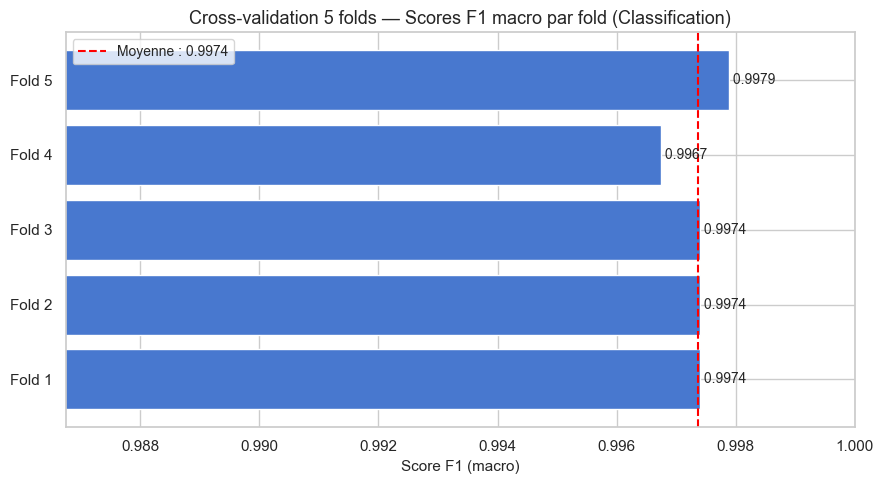

Figure sauvegardée : figures/CLF_cross_validation_f1.png


In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

folds = [f'Fold {i+1}' for i in range(len(cv_scores_clf))]
bars = ax.barh(folds, cv_scores_clf, color='#4878CF', edgecolor='white')
ax.axvline(cv_scores_clf.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Moyenne : {cv_scores_clf.mean():.4f}')

for bar, val in zip(bars, cv_scores_clf):
    ax.text(val, bar.get_y() + bar.get_height() / 2,
            f' {val:.4f}', va='center', fontsize=10)

marge = max((cv_scores_clf.max() - cv_scores_clf.min()) * 2, 0.01)
ax.set_xlim(max(0, cv_scores_clf.min() - marge), min(1.0, cv_scores_clf.max() + marge))
ax.set_xlabel('Score F1 (macro)', fontsize=11)
ax.set_title('Cross-validation 5 folds — Scores F1 macro par fold (Classification)', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('figures/CLF_cross_validation_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/CLF_cross_validation_f1.png')

## Section 8 — Évaluation finale sur le jeu de test

Évaluation du modèle optimisé sur `X_test` / `y_test` — données mises de côté depuis le début, jamais utilisées ni pour l'entraînement ni pour la sélection du modèle.  
C'est la seule mesure non biaisée des performances réelles.

In [26]:
# Prédictions sur le jeu de test
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

print('=' * 55)
print('  ÉVALUATION FINALE — JEU DE TEST (données jamais vues)')
print('=' * 55)
print()
print(classification_report(y_test, y_pred_test,
                             target_names=['Non substituable (0)', 'Substituable (1)']))
print(f'AUC-ROC final : {roc_auc_score(y_test, y_proba_test):.4f}')

  ÉVALUATION FINALE — JEU DE TEST (données jamais vues)

                      precision    recall  f1-score   support

Non substituable (0)       1.00      1.00      1.00     19571
    Substituable (1)       0.99      1.00      0.99      1792

            accuracy                           1.00     21363
           macro avg       0.99      1.00      1.00     21363
        weighted avg       1.00      1.00      1.00     21363

AUC-ROC final : 1.0000


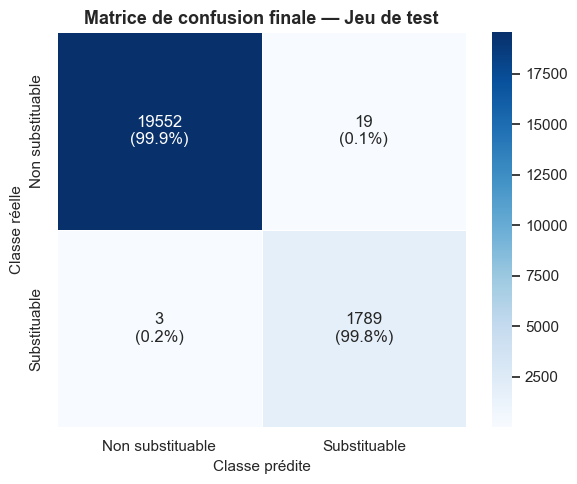

Figure sauvegardée : figures/10_confusion_finale_test.png


In [27]:
# Matrice de confusion finale
fig, ax = plt.subplots(figsize=(6, 5))
cm_test = confusion_matrix(y_test, y_pred_test)

# Annotations avec effectifs et pourcentages
cm_pct = cm_test.astype(float) / cm_test.sum(axis=1)[:, np.newaxis] * 100
annot = np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(row, row_p)]
                   for row, row_p in zip(cm_test, cm_pct)])

sns.heatmap(
    cm_test, annot=annot, fmt='', cmap='Blues',
    xticklabels=['Non substituable', 'Substituable'],
    yticklabels=['Non substituable', 'Substituable'],
    ax=ax, linewidths=0.5, cbar=True
)
ax.set_title('Matrice de confusion finale — Jeu de test', fontsize=13, fontweight='bold')
ax.set_xlabel('Classe prédite', fontsize=11)
ax.set_ylabel('Classe réelle', fontsize=11)

plt.tight_layout()
plt.savefig('figures/10_confusion_finale_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/10_confusion_finale_test.png')

### Interprétation métier

Le Recall classe 1 indique la proportion de liaisons réellement substituables que le modèle identifie correctement.

Concrètement pour ObRail :
- un **faux négatif** (liaison substituable non détectée) = une opportunité de décarbonation non remontée aux décideurs
- un **faux positif** (liaison incorrectement classée substituable) = une recommandation à affiner en aval, moins pénalisant

Un Recall élevé permet à ObRail de construire une liste quasi-exhaustive des corridors prioritaires à soumettre aux ministères des Transports européens, sans risquer d'en omettre.

## Section 9 — Sauvegarde du modèle et des artefacts

Trois fichiers sérialisés via `joblib` dans `models/` :
- `classification_substitution_avion.joblib` : modèle XGBoost optimisé
- `scaler.joblib` : StandardScaler (utile si on intègre la régression logistique au pipeline)
- `encoders.joblib` : LabelEncoders pour `type_train` et `country`

Ces trois artefacts sont nécessaires et suffisants pour reproduire une prédiction à partir de nouvelles données brutes.

In [28]:
import joblib

# Sauvegarde du modèle final
joblib.dump(best_model, 'models/classification_substitution_avion.joblib')
print('Modèle sauvegardé : models/classification_substitution_avion.joblib')

# Sauvegarde du scaler
joblib.dump(scaler, 'models/scaler.joblib')
print('Scaler sauvegardé : models/scaler.joblib')

# Sauvegarde des encodeurs avec leurs classes
joblib.dump(
    {'le_type_train': le_type_train, 'le_country': le_country},
    'models/encoders.joblib'
)
print('Encodeurs sauvegardés : models/encoders.joblib')

# Vérification des fichiers créés
print()
print('Contenu du dossier models/ :')
for f in os.listdir('models'):
    size_kb = os.path.getsize(f'models/{f}') / 1024
    print(f'  {f}  ({size_kb:.0f} KB)')

print()
print('Modèle sauvegardé avec succès.')

Modèle sauvegardé : models/classification_substitution_avion.joblib
Scaler sauvegardé : models/scaler.joblib
Encodeurs sauvegardés : models/encoders.joblib

Contenu du dossier models/ :
  classification_substitution_avion.joblib  (364 KB)
  encoders.joblib  (1 KB)
  scaler.joblib  (1 KB)

Modèle sauvegardé avec succès.


## Section 10 — Script de prédiction standalone (`predict.py`)

Génération de `predict.py` via la commande `%%writefile`.  
Le script charge les artefacts depuis `models/`, encode les entrées catégorielles et retourne la prédiction + la probabilité.  
Usage direct : `python predict.py` — aucune dépendance au notebook.

In [29]:
%%writefile predict.py
"""
predict.py — Pipeline de prédiction minimal pour la substitution avion/train
Usage : python predict.py
"""
import joblib
import pandas as pd


def predict_substitution(distance_km, duration_minutes, n_stops,
                          co2_estime, consommation_totale,
                          type_train, country):
    """
    Prédit si une liaison ferroviaire est candidate à la substitution avion.
    Retourne 1 (substituable) ou 0 (non substituable).
    """
    model = joblib.load('models/classification_substitution_avion.joblib')
    encoders = joblib.load('models/encoders.joblib')

    # Encodage des variables catégorielles
    type_train_enc = encoders['le_type_train'].transform([type_train])[0]
    country_enc = encoders['le_country'].transform([country])[0]

    # Construction du vecteur de features dans le bon ordre
    X = pd.DataFrame([{
        'distance_km': distance_km,
        'duration_minutes': duration_minutes,
        'n_stops': n_stops,
        'co2_estime': co2_estime,
        'consommation_totale': consommation_totale,
        'type_train': type_train_enc,
        'country': country_enc
    }])

    prediction = model.predict(X)[0]
    proba = model.predict_proba(X)[0][1]
    label = "Substituable à l'avion" if prediction == 1 else "Non substituable"

    print(f"Résultat : {label}")
    print(f"Probabilité de substitution : {proba:.2%}")
    return prediction


if __name__ == '__main__':
    # Exemple : Paris → Madrid, 1200 km, 9h45 (585 min), 3 arrêts
    predict_substitution(
        distance_km=1200,
        duration_minutes=585,
        n_stops=3,
        co2_estime=521280,
        consommation_totale=24000,
        type_train='electric',
        country='FR'
    )

Overwriting predict.py


In [30]:
# Test rapide du script
print('Test du script predict.py :')
%run predict.py

Test du script predict.py :
Résultat : Non substituable
Probabilité de substitution : 0.56%


## Section 11 — Prototype d'API REST avec FastAPI (`api.py`)

`api.py` expose le modèle via une route HTTP `POST /predict`.  
Une application externe envoie les caractéristiques d'une liaison en JSON et reçoit la prédiction en retour.

Démarrage local :
```bash
uvicorn api:app --reload
```
Documentation interactive disponible sur `http://localhost:8000/docs` — interface Swagger générée automatiquement par FastAPI.

In [31]:
%%writefile api.py
"""
api.py — Prototype d'API REST pour la prédiction de substitution avion/train
Démarrage : uvicorn api:app --reload
Route principale : POST /predict
Documentation    : http://localhost:8000/docs
"""
from fastapi import FastAPI
from pydantic import BaseModel, Field
import joblib
import pandas as pd

app = FastAPI(
    title="ObRail — API Substitution Avion/Train",
    description="Prédit si une liaison ferroviaire est candidate à remplacer un vol aérien.",
    version="1.0.0"
)

# Chargement des artefacts au démarrage du serveur (une seule fois)
model = joblib.load('models/classification_substitution_avion.joblib')
encoders = joblib.load('models/encoders.joblib')


class LiaisonInput(BaseModel):
    """Schéma des données d'entrée pour une liaison ferroviaire."""
    distance_km: float = Field(..., example=1200.0, description="Distance géographique en km")
    duration_minutes: float = Field(..., example=360.0, description="Durée du trajet en minutes")
    n_stops: int = Field(..., example=2, description="Nombre d'arrêts intermédiaires")
    co2_estime: float = Field(..., example=450000.0, description="Émissions CO2 estimées (gCO2)")
    consommation_totale: float = Field(..., example=20000.0, description="Consommation totale (kWh)")
    type_train: str = Field(..., example="electric", description="Type de traction : 'electric' ou 'diesel'")
    country: str = Field(..., example="FR", description="Code pays : 'FR', 'ES', 'IT' ou 'DE'")


class PredictionOutput(BaseModel):
    """Schéma de la réponse de prédiction."""
    substitution_avion: int
    probabilite: float
    label: str


@app.get("/", tags=["Santé"])
def root():
    """Vérification que l'API est opérationnelle."""
    return {"message": "API ObRail opérationnelle. Utilisez POST /predict"}


@app.post("/predict", response_model=PredictionOutput, tags=["Prédiction"])
def predict(liaison: LiaisonInput):
    """Prédit si une liaison ferroviaire est candidate à la substitution avion."""
    # Encodage des variables catégorielles
    type_train_enc = encoders['le_type_train'].transform([liaison.type_train])[0]
    country_enc = encoders['le_country'].transform([liaison.country])[0]

    # Construction du DataFrame dans le même ordre que lors de l'entraînement
    X = pd.DataFrame([{
        'distance_km': liaison.distance_km,
        'duration_minutes': liaison.duration_minutes,
        'n_stops': liaison.n_stops,
        'co2_estime': liaison.co2_estime,
        'consommation_totale': liaison.consommation_totale,
        'type_train': type_train_enc,
        'country': country_enc
    }])

    prediction = int(model.predict(X)[0])
    proba = float(model.predict_proba(X)[0][1])
    label = "Substituable à l'avion" if prediction == 1 else "Non substituable"

    return PredictionOutput(
        substitution_avion=prediction,
        probabilite=round(proba, 4),
        label=label
    )

Overwriting api.py


### Métriques de monitoring en production

Indicateurs à surveiller une fois l'API déployée :
- **distribution des prédictions** : si la proportion de 1 dérive dans le temps, les données d'entrée ont probablement changé
- **data drift** : comparer les distributions des features en production vs. entraînement (outils : Evidently, WhyLogs)
- **taux d'erreur** : pays inconnu ou type de train invalide → retours 422 à surveiller
- **latence** : P50 / P95 pour garantir une réponse acceptable sous charge

---

## Limites et perspectives

### Limites du modèle

- **Variable cible construite par règles** : `substitution_avion` n'est pas une observation réelle. Le modèle apprend à reproduire une règle déterministe, pas un phénomène mesuré. Les performances seraient probablement inférieures avec de vrais labels terrain.
- **Circularité features / cible** : `distance_km` et `duration_minutes` définissent à la fois X et y — les scores élevés s'expliquent en partie par là.
- **Pas de dimension temporelle** : aucune donnée sur la saison, le jour de semaine ou les horaires — or la fréquence de service et les tarifs aériens varient fortement.
- **Pas de données tarifaires** : la compétitivité économique (prix du billet) est absente du modèle.
- **4 pays uniquement** : la généralisation à d'autres réseaux européens n'est pas testée.

### Pistes d'amélioration

- collecter des vrais labels : enquêtes voyageurs, données de réservation multimodales, statistiques Eurostat
- enrichir avec des données tarifaires, de ponctualité et de fréquence de service
- intégrer les émissions CO2 avion sur les mêmes corridors pour un comparatif direct
- agréger par O-D pairs plutôt que par trajet individuel
- mettre en place un pipeline de monitoring (Evidently) pour déclencher le réentraînement en cas de drift